In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

%matplotlib inline

In [10]:
fund = pd.read_csv("../data/processed/clean_fund_master.csv")

nav = pd.read_csv("../data/processed/clean_nav_history.csv")

aum = pd.read_csv("../data/processed/clean_aum.csv")

sip = pd.read_csv("../data/processed/clean_sip.csv")

category = pd.read_csv("../data/processed/clean_category_inflows.csv")

folio = pd.read_csv("../data/processed/clean_folio_count.csv")

performance = pd.read_csv("../data/processed/clean_performance.csv")

transactions = pd.read_csv("../data/processed/clean_transactions.csv")

holdings = pd.read_csv("../data/processed/clean_holdings.csv")

benchmark = pd.read_csv("../data/processed/clean_benchmark.csv")

In [11]:
datasets = {
    "Fund Master": fund,
    "NAV History": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Performance": performance,
    "Transactions": transactions,
    "Holdings": holdings,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print("="*50)
    print(name)
    print(df.shape)

Fund Master
(40, 15)
NAV History
(46000, 3)
AUM
(90, 5)
SIP
(48, 6)
Category
(144, 3)
Folio
(21, 6)
Performance
(40, 19)
Transactions
(32778, 13)
Holdings
(322, 8)
Benchmark
(8050, 3)


In [12]:
nav["date"] = pd.to_datetime(nav["date"])

aum["date"] = pd.to_datetime(aum["date"])

sip["month"] = pd.to_datetime(sip["month"])

category["month"] = pd.to_datetime(category["month"])

folio["month"] = pd.to_datetime(folio["month"])

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

holdings["portfolio_date"] = pd.to_datetime(
    holdings["portfolio_date"]
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

print("Date columns converted successfully!")

Date columns converted successfully!


In [13]:
summary = pd.DataFrame({
    "Dataset":[
        "Fund Master",
        "NAV",
        "AUM",
        "SIP",
        "Category",
        "Folio",
        "Performance",
        "Transactions",
        "Holdings",
        "Benchmark"
    ],

    "Rows":[
        len(fund),
        len(nav),
        len(aum),
        len(sip),
        len(category),
        len(folio),
        len(performance),
        len(transactions),
        len(holdings),
        len(benchmark)
    ]
})

summary

,Dataset,Rows
0,Fund Master,40
1,NAV,46000
2,AUM,90
3,SIP,48
4,Category,144
5,Folio,21
6,Performance,40
7,Transactions,32778
8,Holdings,322
9,Benchmark,8050


In [14]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022–2026)"
)

fig.update_layout(
    width=1100,
    height=600
)

fig.show()

In [ ]:
# Extract year from date
aum["year"] = aum["date"].dt.year

# Group AUM by year and fund house
aum_year = (
    aum.groupby(["year", "fund_house"])["aum_crore"]
    .sum()
    .reset_index()
)

aum_year.head()

,year,fund_house,aum_crore
0,2022,Aditya Birla Sun Life MF,563000
1,2022,Axis Mutual Fund,490000
2,2022,DSP Mutual Fund,222000
3,2022,HDFC Mutual Fund,880000
4,2022,ICICI Prudential MF,953000


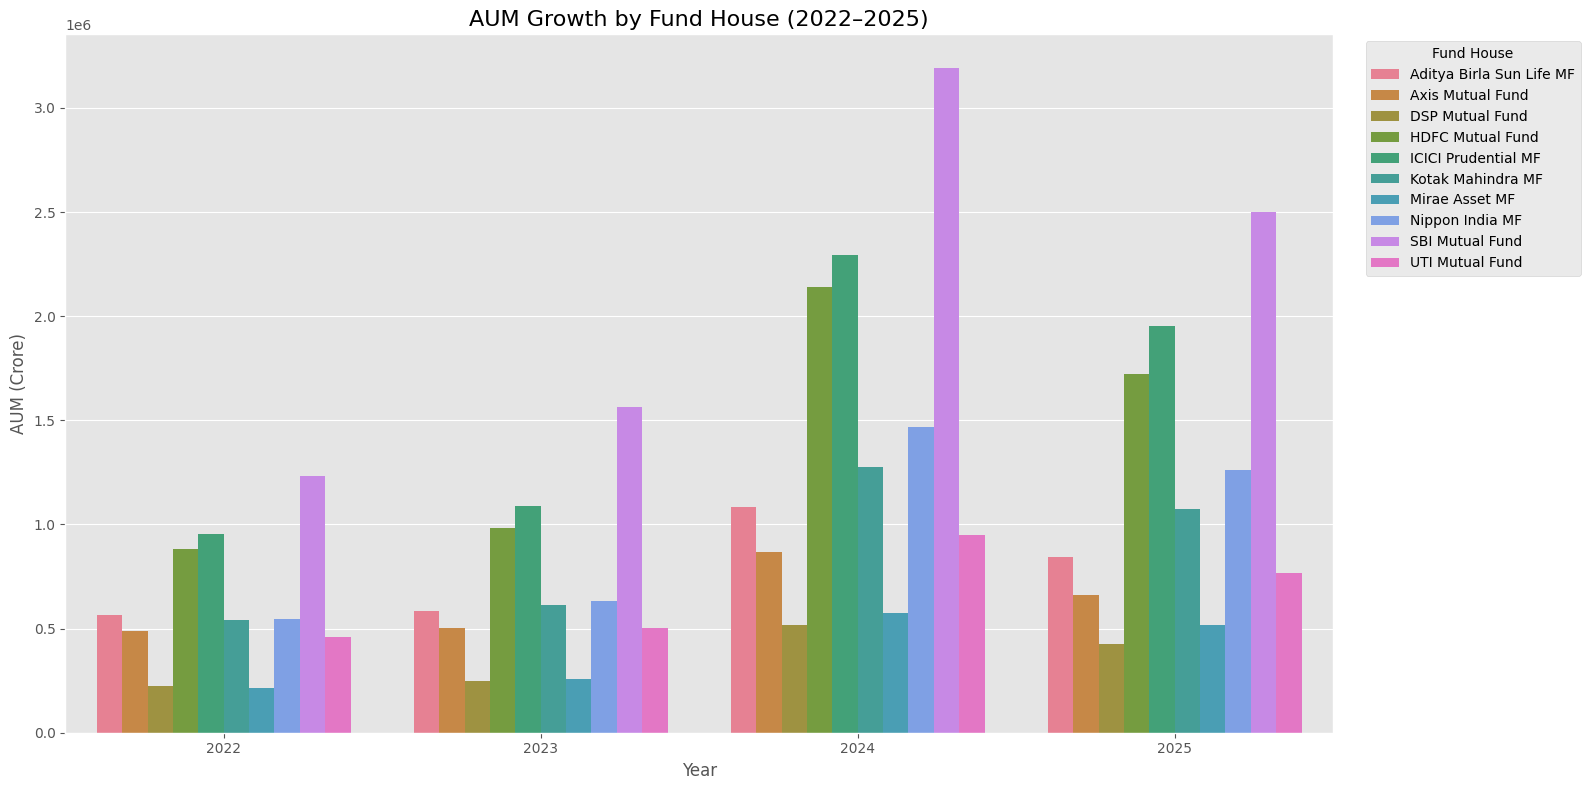

In [ ]:
plt.figure(figsize=(16,8))

sns.barplot(
    data=aum_year,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("AUM (Crore)", fontsize=12)

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

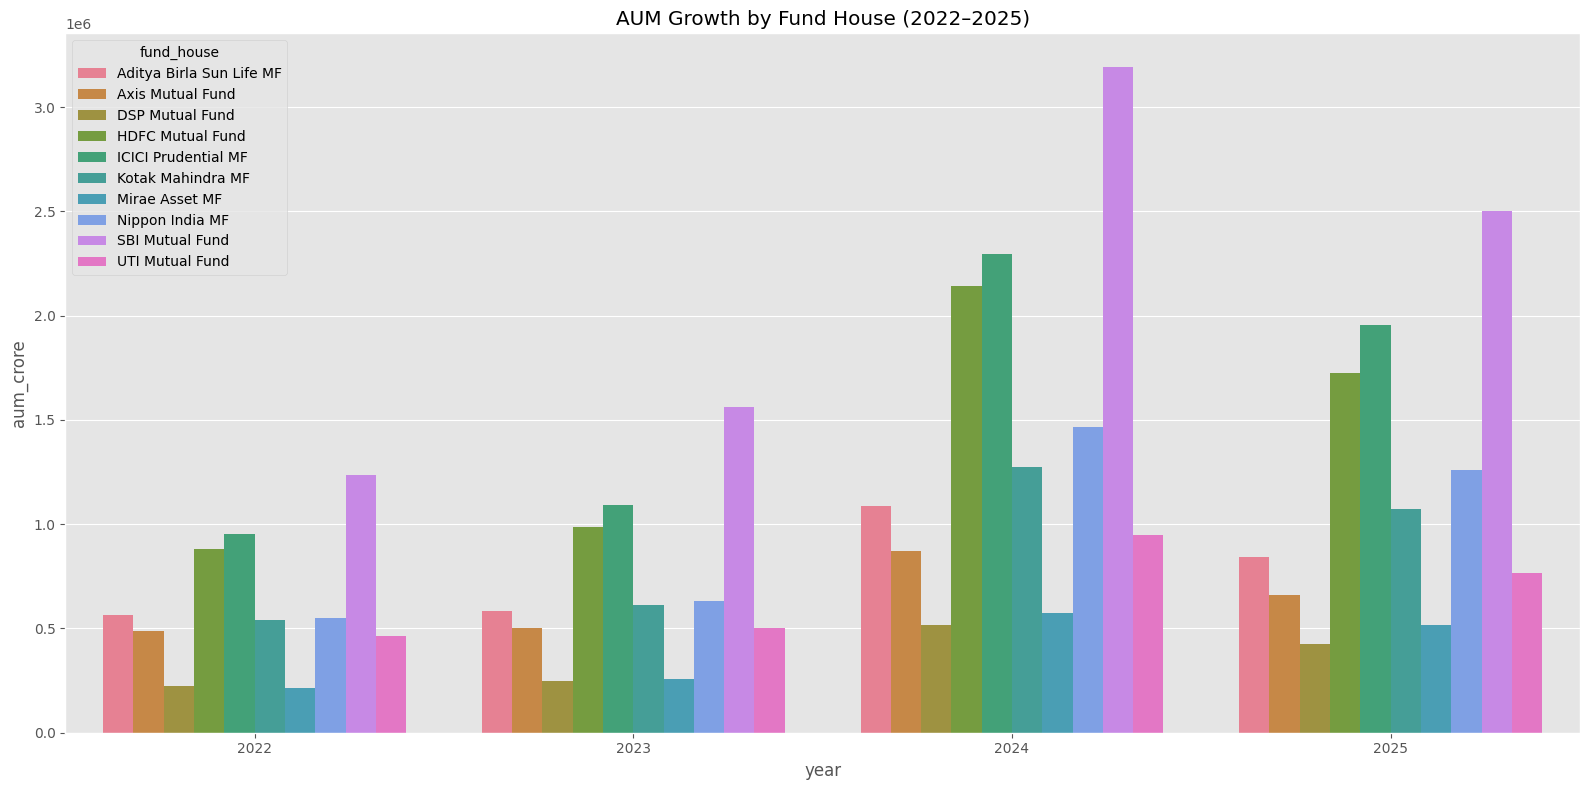

In [ ]:
plt.figure(figsize=(16,8))

sns.barplot(
    data=aum_year,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.tight_layout()

plt.savefig("../reports/aum_growth.png", dpi=300)

plt.show()

In [ ]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)"
)

fig.update_layout(
    width=1200,
    height=600,
    xaxis_title="Month",
    yaxis_title="SIP Inflow (Crore ₹)"
)

fig.show()

In [ ]:
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)"
)

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f"Highest: ₹{max_row['sip_inflow_crore']:,.0f} Cr",
    showarrow=True,
    arrowhead=2,
    bgcolor="yellow"
)

fig.update_layout(
    width=1200,
    height=600
)

fig.show()

In [ ]:
fig.write_html("../reports/sip_trend.html")

NameError: name 'fig' is not defined

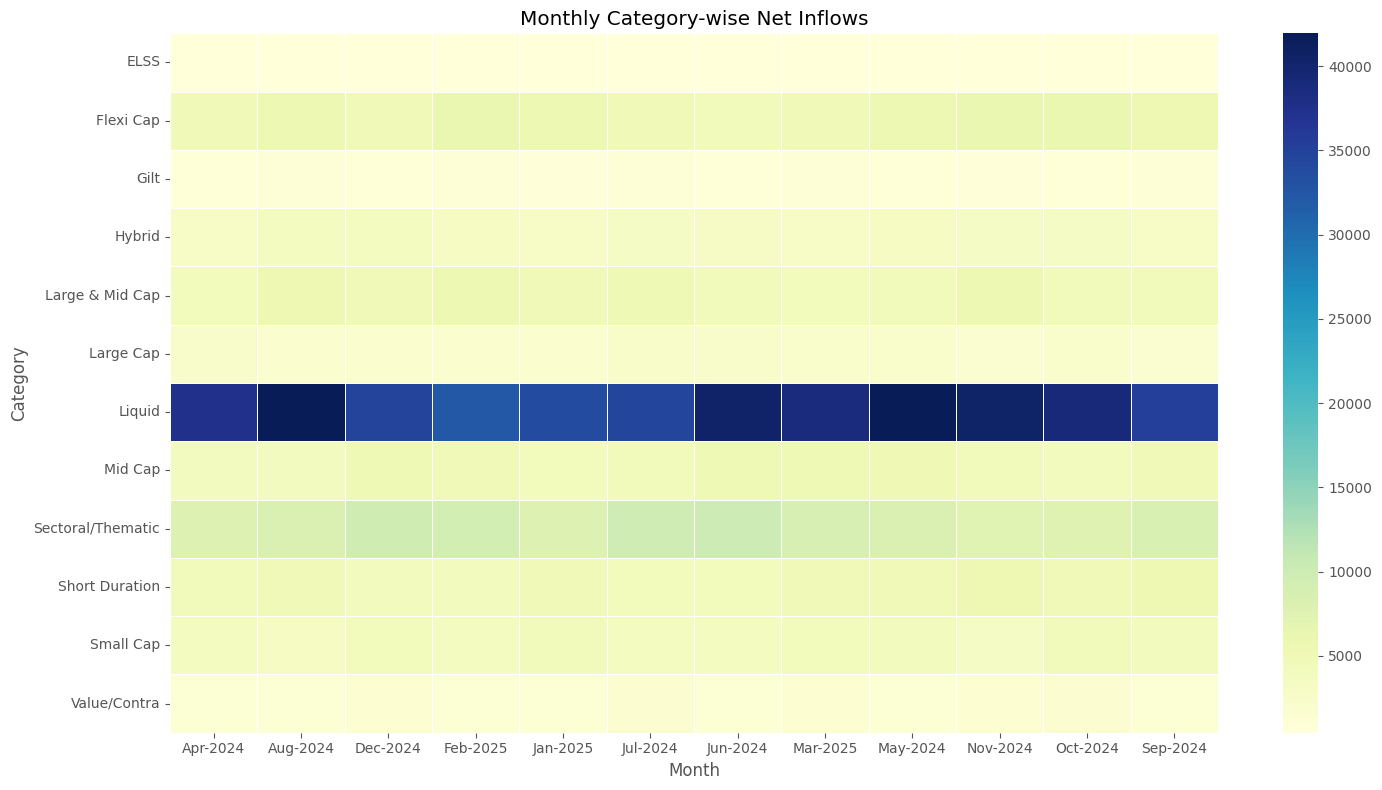

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

category = pd.read_csv("../data/processed/clean_category_inflows.csv")

category["month"] = pd.to_datetime(category["month"]).dt.strftime("%b-%Y")

pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(15,8))

sns.heatmap(
    pivot,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Monthly Category-wise Net Inflows")
plt.xlabel("Month")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

In [17]:
plt.savefig("../reports/category_heatmap.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [18]:
transactions = pd.read_csv("../data/processed/clean_transactions.csv")

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


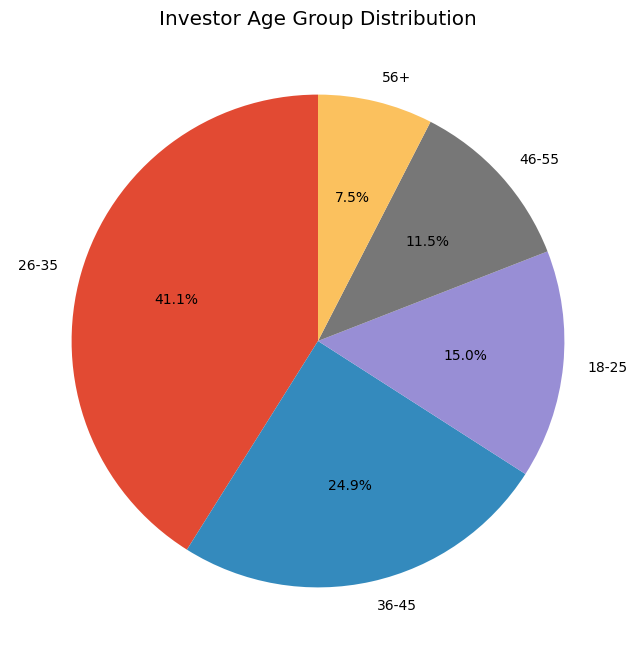

In [19]:
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.show()

In [20]:
plt.savefig("../reports/age_group_distribution.png", dpi=300)

<Figure size 640x480 with 0 Axes>

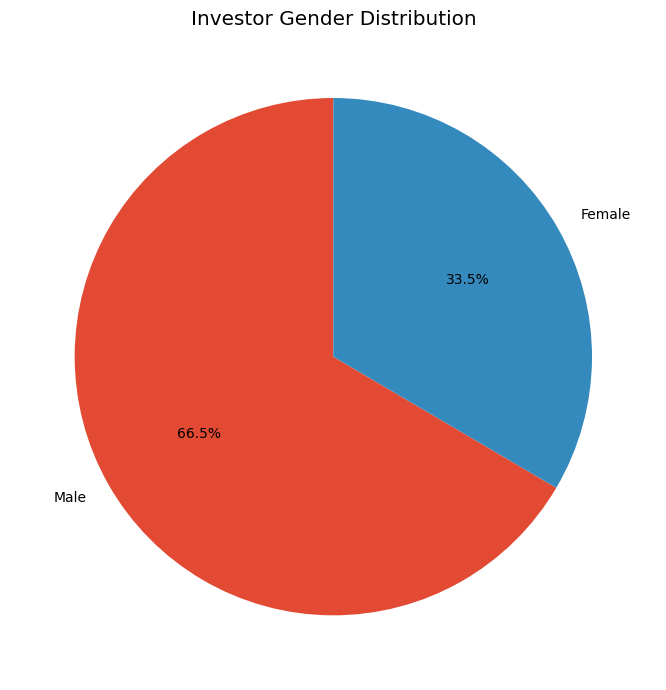

In [72]:
gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Gender Distribution")

plt.tight_layout()

# Save the chart
plt.savefig(
    "../reports/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.savefig("../reports/gender_distribution.png", dpi=300)
plt.close()

In [25]:
plt.savefig("../reports/gender_distribution.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [26]:
# 6. Geographic Distribution
state_sip = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

state_sip.head()

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
Name: amount_inr, dtype: int64

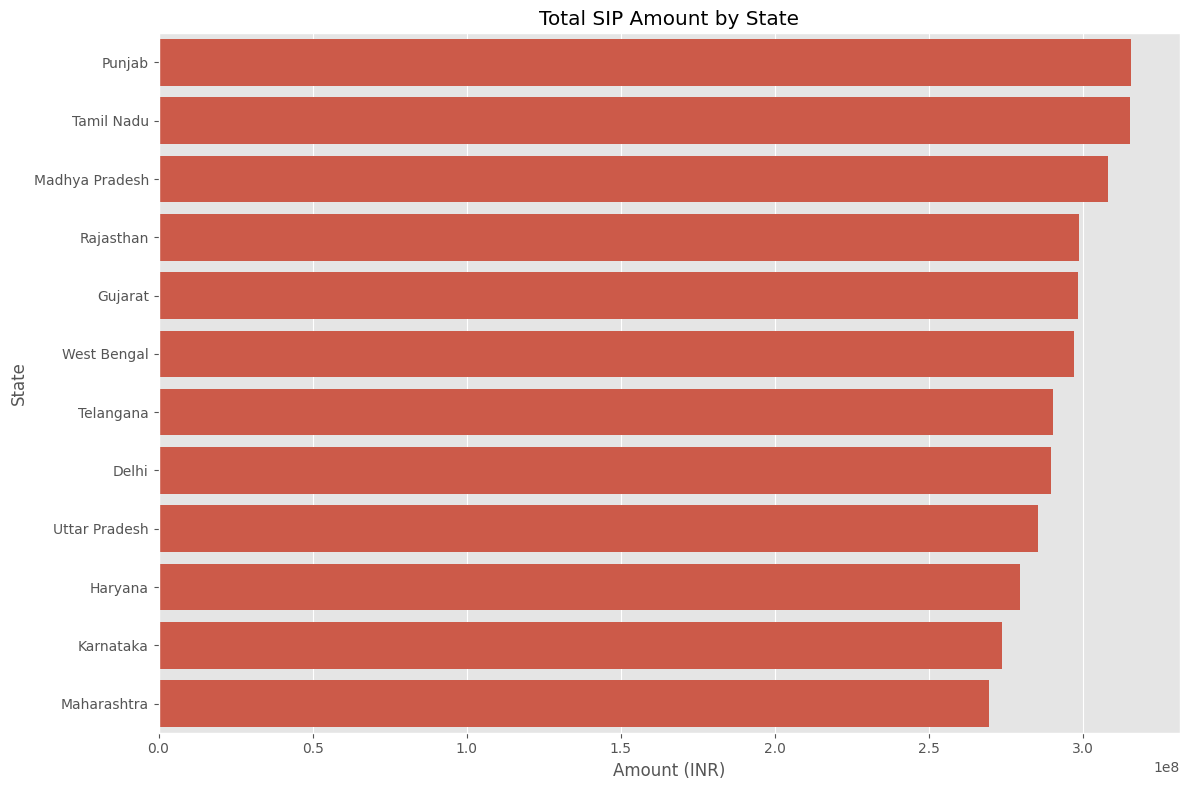

In [71]:
plt.figure(figsize=(12,8))

sns.barplot(
    x=state_sip.values,
    y=state_sip.index
)

plt.title("Total SIP Amount by State")
plt.xlabel("Amount (INR)")
plt.ylabel("State")

plt.tight_layout()
plt.savefig("../reports/state_sip.png", dpi=300)
plt.show()
plt.close()

In [28]:
plt.savefig("../reports/state_sip.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [29]:
tier_counts = transactions["city_tier"].value_counts()

tier_counts

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

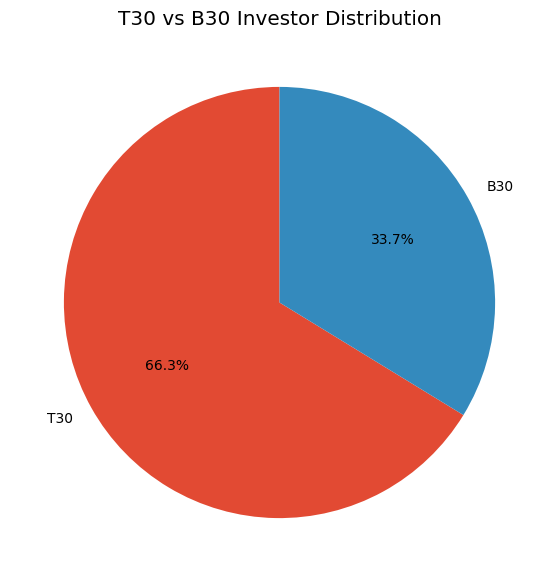

In [70]:
plt.figure(figsize=(7,7))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 Investor Distribution")
plt.savefig("../reports/city_tier_distribution.png", dpi=300)
plt.show()
plt.close()

In [31]:
plt.savefig("../reports/city_tier_distribution.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [32]:
folio["month"] = pd.to_datetime(folio["month"])

folio = folio.sort_values("month")

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


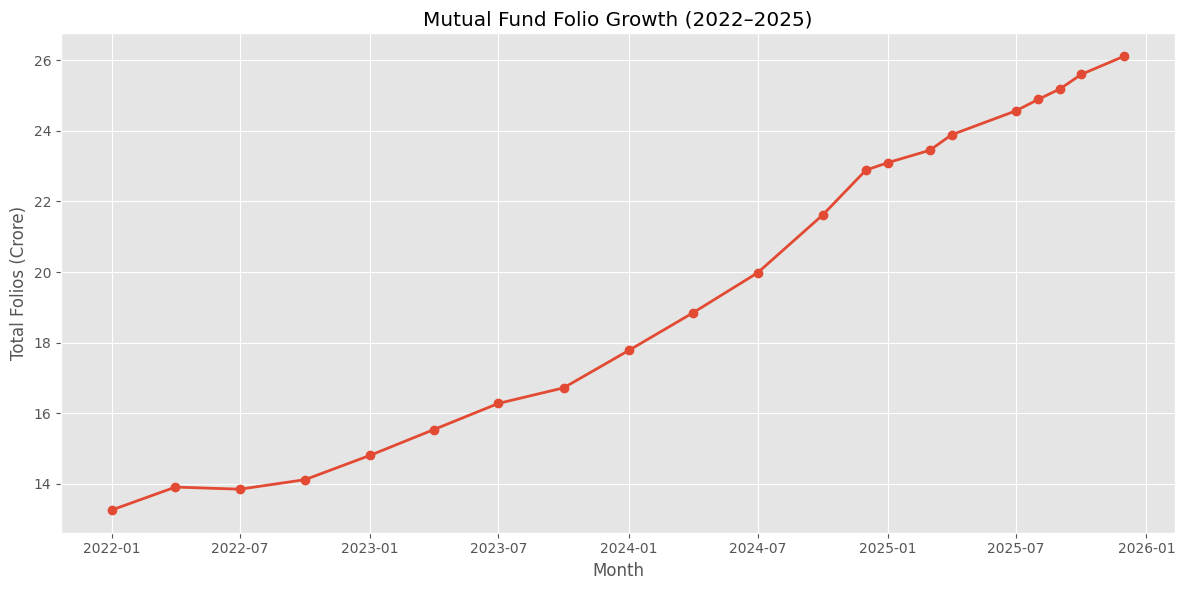

In [33]:
plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2
)

plt.title("Mutual Fund Folio Growth (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.tight_layout()

plt.show()

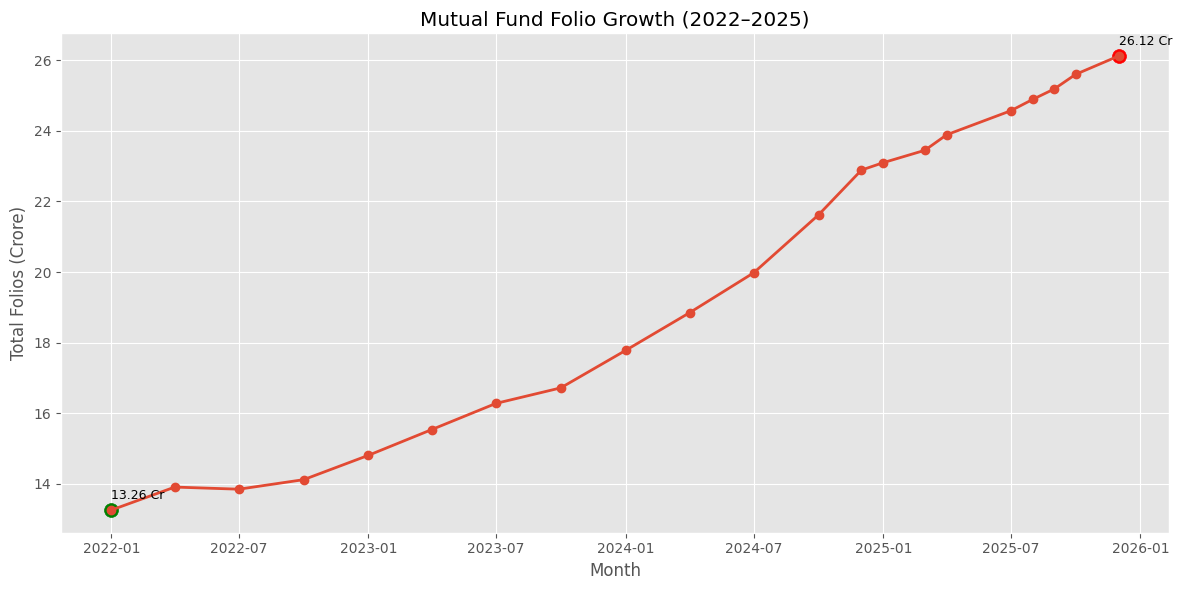

In [69]:
plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2
)

# First value
plt.scatter(
    folio.iloc[0]["month"],
    folio.iloc[0]["total_folios_crore"],
    color="green",
    s=100
)

plt.text(
    folio.iloc[0]["month"],
    folio.iloc[0]["total_folios_crore"] + 0.3,
    f'{folio.iloc[0]["total_folios_crore"]:.2f} Cr',
    fontsize=9
)

# Last value
plt.scatter(
    folio.iloc[-1]["month"],
    folio.iloc[-1]["total_folios_crore"],
    color="red",
    s=100
)

plt.text(
    folio.iloc[-1]["month"],
    folio.iloc[-1]["total_folios_crore"] + 0.3,
    f'{folio.iloc[-1]["total_folios_crore"]:.2f} Cr',
    fontsize=9
)

plt.title("Mutual Fund Folio Growth (2022–2025)")

plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.tight_layout()
plt.savefig("../reports/folio_growth.png", dpi=300)
plt.show()
plt.close()

In [35]:
plt.savefig("../reports/folio_growth.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [36]:
# 8. NAV Return Correlation Matrix
selected_funds = nav["amfi_code"].unique()[:10]

selected_funds

array([100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886,
       102887, 118632])

In [37]:
nav_10 = nav[nav["amfi_code"].isin(selected_funds)]

nav_10.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [38]:
nav_10 = nav_10.sort_values(["amfi_code", "date"])

nav_10["daily_return"] = (
    nav_10.groupby("amfi_code")["nav"]
    .pct_change()
)

nav_10.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [39]:
returns = nav_10.pivot(
    index="date",
    columns="amfi_code",
    values="daily_return"
)

returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793


In [40]:
corr = returns.corr()

corr

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384
101208,-0.033773,0.018455,0.007864,-0.027230,-0.007530,1.000000,-0.001436,0.014307,0.036547,0.003507
102885,-0.093533,-0.001038,-0.034228,0.001570,-0.005929,-0.001436,1.000000,0.020691,-0.036704,-0.000285
102886,-0.005867,0.013754,-0.018166,0.007229,0.004860,0.014307,0.020691,1.000000,-0.007865,-0.039886
102887,-0.023316,-0.005648,-0.036647,-0.006490,0.002304,0.036547,-0.036704,-0.007865,1.000000,0.001248


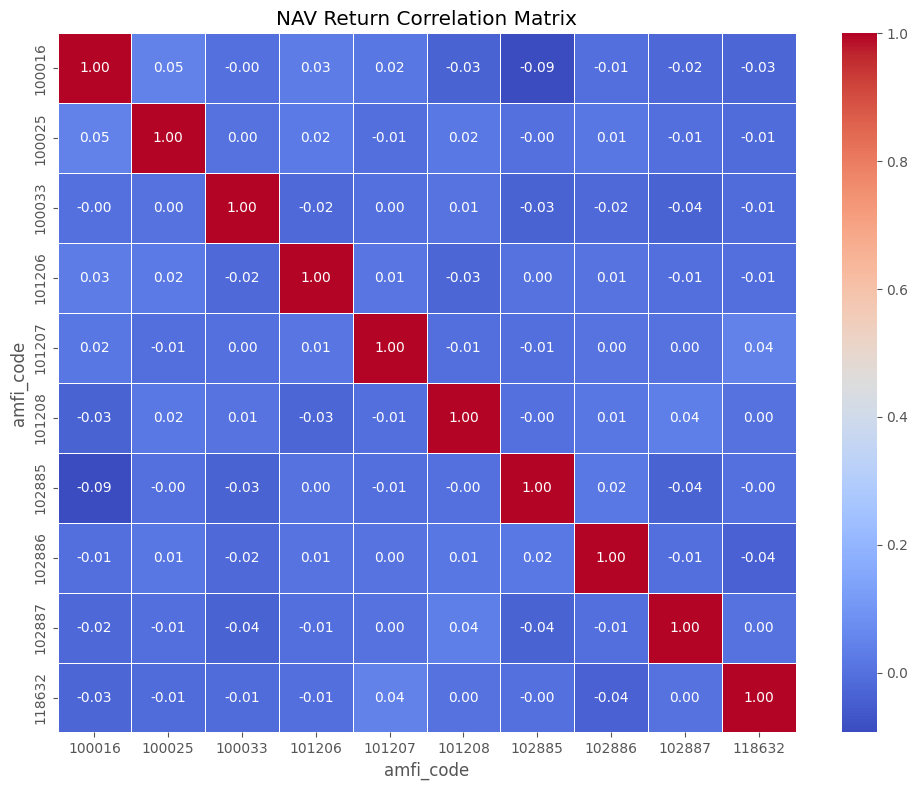

In [68]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("NAV Return Correlation Matrix")

plt.tight_layout()
plt.savefig("../reports/nav_correlation.png", dpi=300)
plt.show()
plt.close()

In [42]:
plt.savefig("../reports/nav_correlation.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [43]:
# 9. Sector Allocation Analysis
sector = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector.head()

sector
Banking       652.26
IT            455.47
Pharma        407.45
Automobile    323.65
Utilities     265.54
Name: weight_pct, dtype: float64

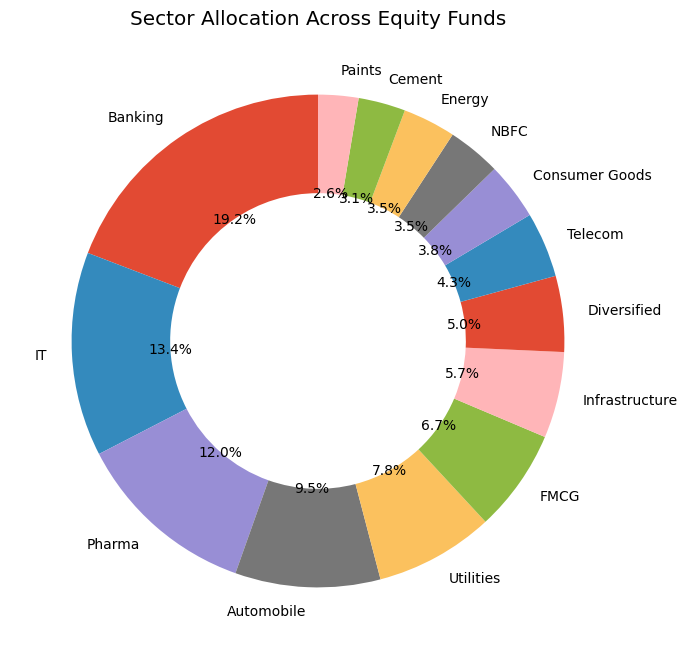

In [62]:
plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation Across Equity Funds")
plt.savefig("../reports/sector_allocation.png", dpi=300)
plt.show()
plt.close()

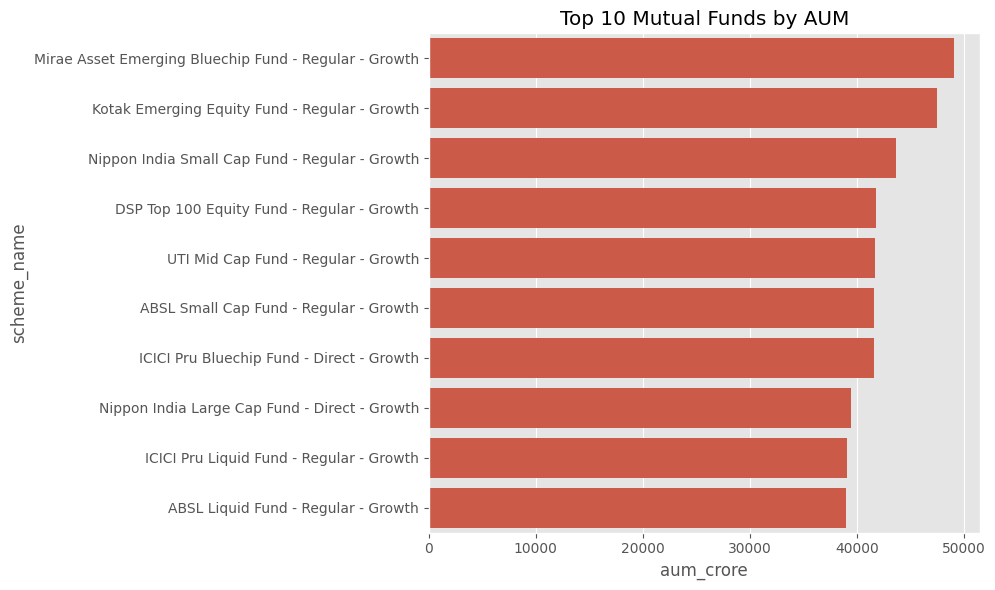

In [63]:
top10 = (
    performance.sort_values("aum_crore", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="aum_crore",
    y="scheme_name"
)

plt.title("Top 10 Mutual Funds by AUM")

plt.tight_layout()

plt.savefig("../reports/expense_ratio_distribution.png", dpi=300)

plt.show()
plt.close()

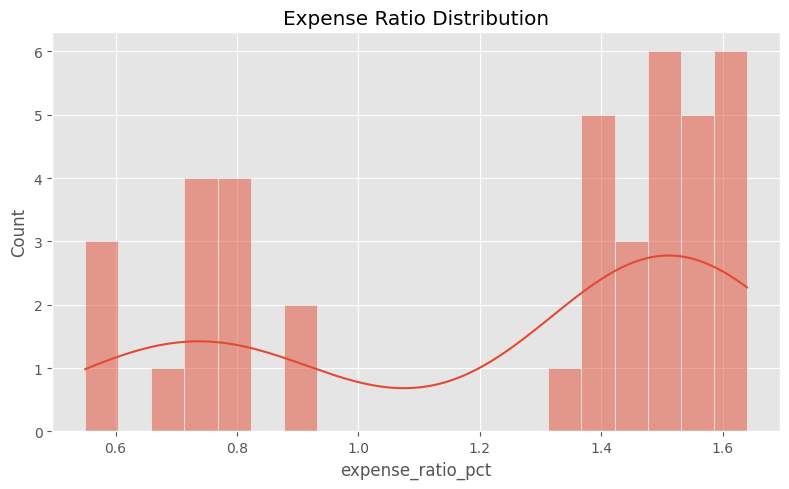

In [64]:
plt.figure(figsize=(8,5))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=20,
    kde=True
)

plt.title("Expense Ratio Distribution")

plt.tight_layout()

plt.savefig("../reports/expense_ratio_distribution.png", dpi=300)

plt.show()
plt.close()

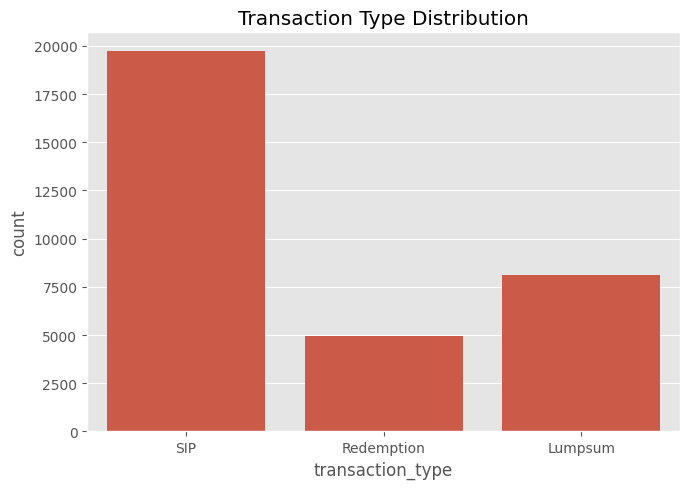

In [65]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=transactions,
    x="transaction_type"
)

plt.title("Transaction Type Distribution")

plt.tight_layout()

plt.savefig("../reports/transaction_type_distribution.png", dpi=300)

plt.show()
plt.close()

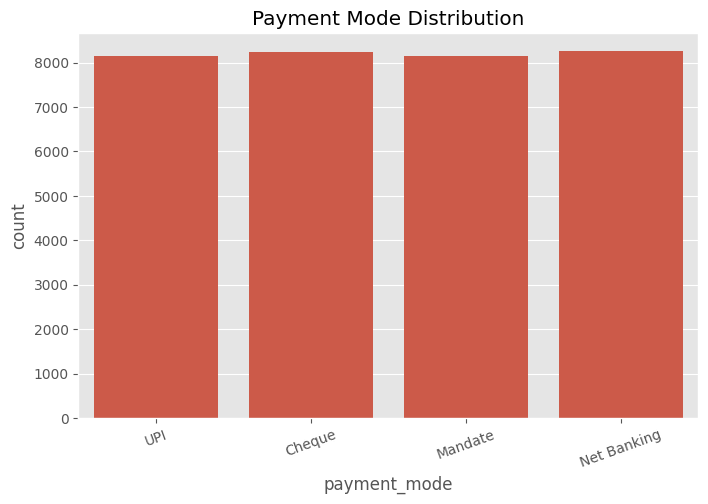

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [60]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=transactions,
    x="payment_mode"
)

plt.title("Payment Mode Distribution")

plt.xticks(rotation=20)

plt.show()
plt.tight_layout()

plt.show()
plt.savefig("../reports/payment_mode_distribution.png", dpi=300)


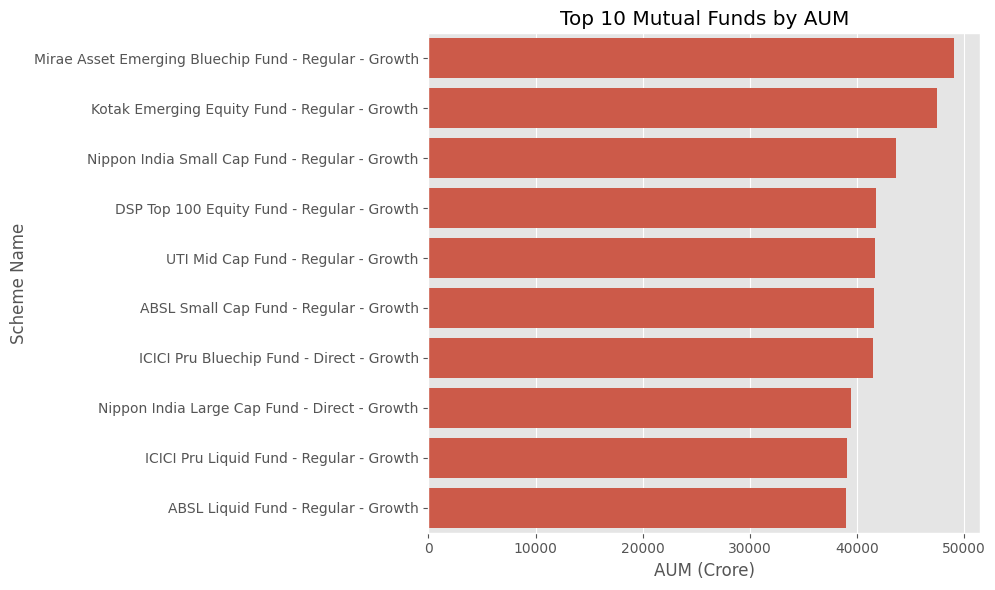

In [66]:
top10 = (
    performance.sort_values("aum_crore", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="aum_crore",
    y="scheme_name"
)

plt.title("Top 10 Mutual Funds by AUM")
plt.xlabel("AUM (Crore)")
plt.ylabel("Scheme Name")

plt.tight_layout()

# Save the chart
plt.savefig("../reports/top10_mutual_funds_aum.png", dpi=300)

# Display the chart
plt.show()
plt.close()


In [67]:
plt.tight_layout()

plt.savefig("../reports/risk_grade_distribution.png", dpi=300)

plt.show()
plt.close()

<Figure size 640x480 with 0 Axes>

In [56]:
plt.tight_layout()

plt.savefig("../reports/transaction_type_distribution.png", dpi=300)

plt.show()

<Figure size 640x480 with 0 Axes>